In [ ]:
# 1. Setup & Memory Guardrails

import os

# Prevent TensorFlow from over-allocating pinned host memory
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Limit GPU growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Memory growth error:", e)

from tensorflow.keras import layers, models, callbacks

DATA_DIR = 'data/raw/plants_species'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
KEEP_RATIO = 0.25
AUTOTUNE = tf.data.AUTOTUNE

I0000 00:00:1791061666.445902    8586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791061669.017088    8586 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791061672.737444    8586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1791061682.944495    8586 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries co

In [2]:
# 2. Load & Sample Dataset Directly from Existing Folders

import glob

# Map crop names to their respective existing folders
CROP_DIRS = {
    'apple': 'data/raw/apple_color',
    'cherry': 'data/raw/cherry_color',
    'corn': 'data/raw/corn_color',
    'grape': 'data/raw/grape_color',
    'peach': 'data/raw/peach_color',
    'pepper': 'data/raw/pepper_color',
    'potato': 'data/raw/potato_color',
    'strawberry': 'data/raw/strawberry_color',
    'tomato': 'data/raw/tomato_color'
}

all_image_paths = []
all_labels = []
class_names = sorted(list(CROP_DIRS.keys()))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Collect all images from existing directories
for crop_name, crop_path in CROP_DIRS.items():
    if not os.path.exists(crop_path):
        print(f"Warning: {crop_path} does not exist, skipping.")
        continue
    
    # Recursively find all images in this crop folder
    images = glob.glob(f"{crop_path}/*/*.[jJ][pP][gG]") + \
             glob.glob(f"{crop_path}/*/*.[pP][nN][gG]") + \
             glob.glob(f"{crop_path}/*/*.[jJ][pP][eE][gG]")
    
    all_image_paths.extend(images)
    all_labels.extend([class_to_idx[crop_name]] * len(images))

print(f"Total images found across all crops: {len(all_image_paths)}")
print(f"Classes ({len(class_names)}): {class_names}")

if len(all_image_paths) == 0:
    raise ValueError("No images found! Check that data/raw/*_color directories exist and contain images.")

# Shuffle deterministically
np.random.seed(SEED)
indices = np.random.permutation(len(all_image_paths))
all_image_paths = np.array(all_image_paths)[indices]
all_labels = np.array(all_labels)[indices]

# Apply KEEP_RATIO (keep only the requested percentage)
total_keep = max(1, int(len(all_image_paths) * KEEP_RATIO))
sampled_paths = all_image_paths[:total_keep]
sampled_labels = all_labels[:total_keep]

# 80% Train, 10% Val, 10% Test
train_end = int(0.8 * total_keep)
val_end = int(0.9 * total_keep)

train_paths, train_y = sampled_paths[:train_end], sampled_labels[:train_end]
val_paths, val_y = sampled_paths[train_end:val_end], sampled_labels[train_end:val_end]
test_paths, test_y = sampled_paths[val_end:], sampled_labels[val_end:]

print(f"Using {total_keep} images ({int(KEEP_RATIO * 100)}%):")
print(f"  - Train: {len(train_paths)}")
print(f"  - Val:   {len(val_paths)}")
print(f"  - Test:  {len(test_paths)}")

# Function to parse file paths to images
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

# Build tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_y)) \
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_y)) \
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH_SIZE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_y)) \
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH_SIZE)

num_classes = len(class_names)

Total images found across all crops: 40000
Classes (9): ['apple', 'cherry', 'corn', 'grape', 'peach', 'pepper', 'potato', 'strawberry', 'tomato']
Using 10000 images (25%):
  - Train: 8000
  - Val:   1000
  - Test:  1000


W0000 00:00:1791061684.728027    8586 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1791061685.651017    8586 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1791061685.653074    8586 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5198 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


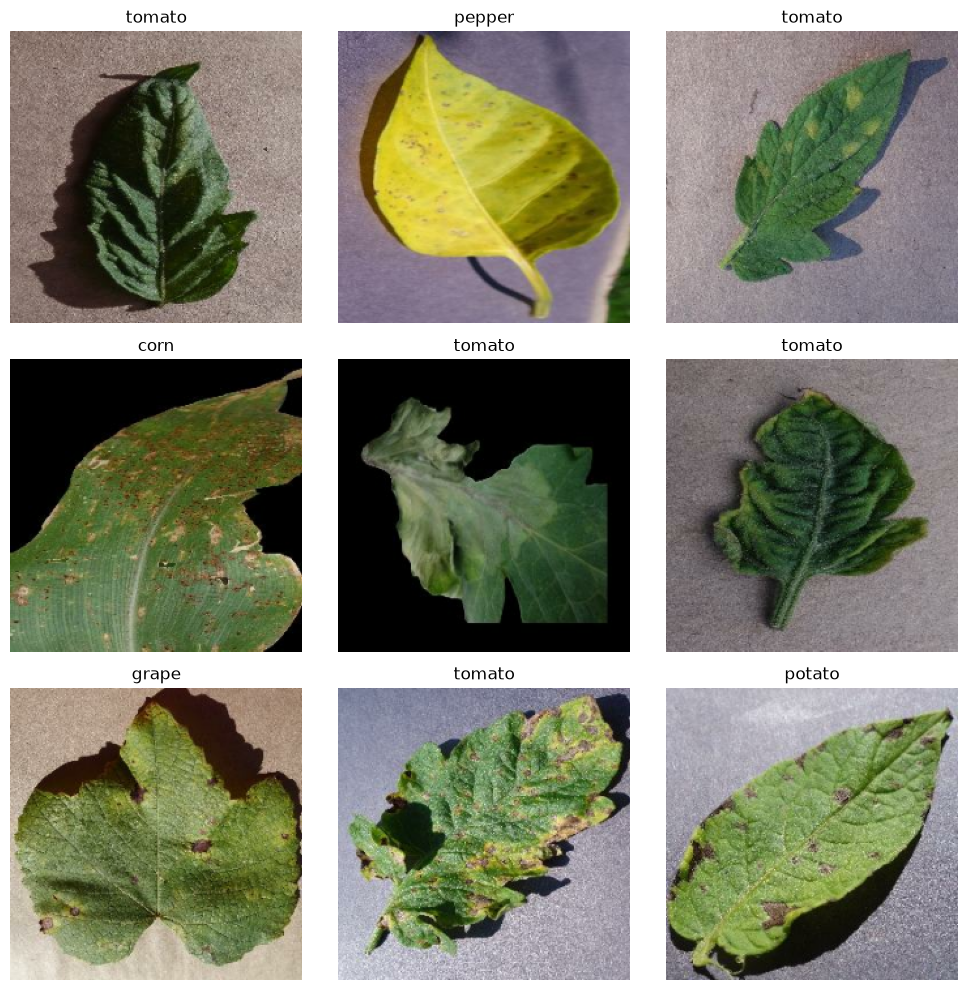

In [3]:

# 3. Data Sanity Check


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# 4. Lightweight Pipeline Optimization (No RAM Bloat)

# Shuffle with a modest buffer (128-256 batches) instead of 1000
# Drop .cache() to avoid overloading WSL2 host memory
train_ds = train_ds.shuffle(buffer_size=128).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:

# 5. Model Architecture (MobileNetV2 Backbone)


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pretrained weights

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Preprocessing and Augmentation
    layers.Rescaling(1.0 / 127.5, offset=-1.0),  # Scales to [-1, 1] for MobileNetV2
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),

    # Feature Extractor
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Classifier Head
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,233 (9.26 MB)

 Trainable params: 167,689 (655.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [6]:

# 6. Training


os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)

training_callbacks = [
    callbacks.TensorBoard(log_dir='logs/species_classifier'),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=training_callbacks
)

/home/pranay/ml_workspace/ml-env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/15


I0000 00:00:1791061693.086216    8852 cuda_dnn.cc:461] Loaded cuDNN version 92600


500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.8167 - loss: 0.5717 - val_accuracy: 0.9630 - val_loss: 0.1399 - learning_rate: 3.0000e-04
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.9279 - loss: 0.2131 - val_accuracy: 0.9640 - val_loss: 0.1052 - learning_rate: 3.0000e-04
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.9439 - loss: 0.1656 - val_accuracy: 0.9730 - val_loss: 0.0845 - learning_rate: 3.0000e-04
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9473 - loss: 0.1550 - val_accuracy: 0.9760 - val_loss: 0.0759 - learning_rate: 3.0000e-04
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.9571 - loss: 0.1268 - val_accuracy: 0.9750 - val_loss: 0.0702 - learning_rate: 3.0000e-04
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9586 - loss: 0.1165 - val_accuracy: 0.9770 - val_loss: 0.0671 - learning_rate: 3.0000e-04
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accurac

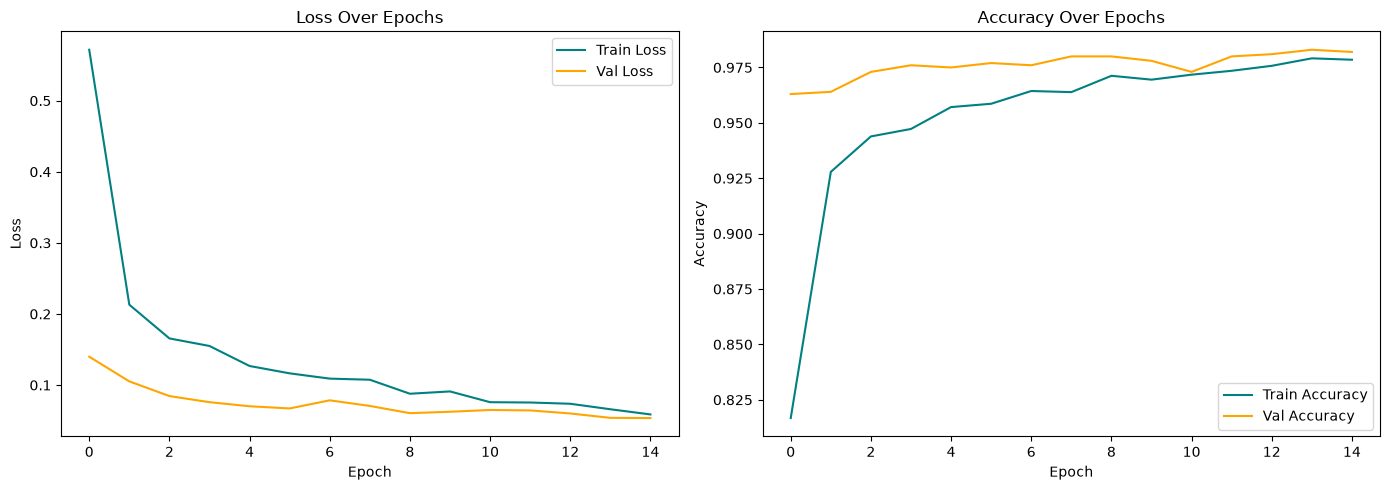

In [7]:

# 7. Performance Visualizations


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
ax1.plot(history.history['loss'], label='Train Loss', color='teal')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy Curves
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()

os.makedirs('reports/figures', exist_ok=True)
fig.savefig('reports/figures/species_training_performance.png', dpi=300, bbox_inches='tight')

plt.show()

In [8]:

# 8. Test Set Evaluation & Export


test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

# Save model
model_path = os.path.join('models', 'species_classifier.keras')
model.save(model_path)
print(f"Model saved to {model_path}")

# Save class labels text file for inference
labels_path = os.path.join('models', 'species_labels.txt')
with open(labels_path, 'w') as f:
    f.write('\n'.join(class_names))
print(f"Labels saved to {labels_path}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9870 - loss: 0.0448

Final Test Loss: 0.0448
Final Test Accuracy: 98.70%
Model saved to models/species_classifier.keras
Labels saved to models/species_labels.txt


In [ ]:
import random
import os
import tensorflow as tf 
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
Path: data/raw/peach_color/Peach___healthy/0305b105-d0e7-4c3d-9a10-e9f0d7d3c4e0___Rutg._HL 3564.JPG
Actual:    peach
Predicted: peach (100.00%)


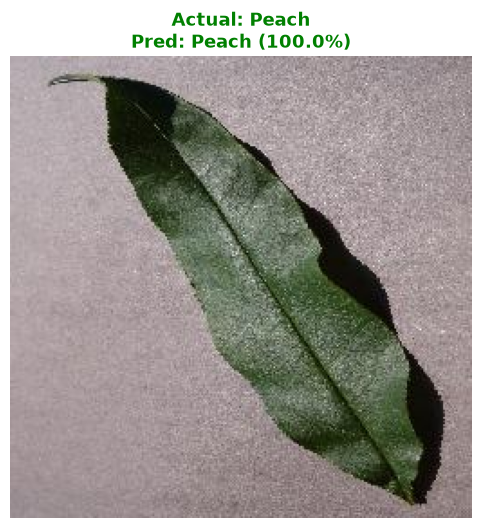

In [64]:
# 9. Single Image Inference with Actual vs. Predicted Labels


# Load trained model and class labels
model_path = os.path.join('models', 'species_classifier.keras')
labels_path = os.path.join('models', 'species_labels.txt')

loaded_model = tf.keras.models.load_model(model_path)

with open(labels_path, 'r') as f:
    loaded_labels = [line.strip() for line in f.readlines()]

# Locate sample images
sample_images = glob.glob('data/raw/*_color/*/*.[jJ][pP][gG]') + \
                glob.glob('data/raw/*_color/*/*.[pP][nN][gG]')

if not sample_images:
    raise FileNotFoundError("No sample images found in data/raw/*_color/!")


sample_image_path = random.choice(sample_images)

# Extract actual label from the folder path (e.g., 'data/raw/apple_color/...' -> 'apple')
path_parts = Path(sample_image_path).parts
crop_folder = [p for p in path_parts if p.endswith('_color')][0]
actual_class = crop_folder.replace('_color', '').lower()

# Read and verify image
img = cv2.imread(sample_image_path)
if img is None:
    raise ValueError(f"Could not load image at path: {sample_image_path}")

# Preprocess
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resized_img = cv2.resize(img_rgb, (224, 224))
input_tensor = np.expand_dims(resized_img, axis=0)

# Predict
predictions = loaded_model.predict(input_tensor)
predicted_idx = np.argmax(predictions[0])
predicted_class = loaded_labels[predicted_idx]
confidence = float(predictions[0][predicted_idx]) * 100

# Console print
print(f"Path: {sample_image_path}")
print(f"Actual:    {actual_class}")
print(f"Predicted: {predicted_class} ({confidence:.2f}%)")

# Display with color-coded title (Green if match, Red if mismatch)
is_correct = actual_class == predicted_class.lower()
title_color = 'green' if is_correct else 'red'

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(
    f"Actual: {actual_class.capitalize()}\nPred: {predicted_class.capitalize()} ({confidence:.1f}%)",
    fontsize=13,
    fontweight='bold',
    color=title_color
)
plt.axis("off")
plt.show()